### Importing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


### EDA

In [7]:
df.shape

(10000, 6)

In [8]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(127)

In [10]:
df = df.drop_duplicates()

In [11]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   object 
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 539.9+ KB


In [32]:
df["Extracurricular Activities"].value_counts()

Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours Studied,9873.0,4.992100,2.589081,1.0,3.0,5.0,7.0,9.0
Previous Scores,9873.0,69.441102,17.325601,40.0,54.0,69.0,85.0,99.0
Sleep Hours,9873.0,6.531652,1.697683,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,9873.0,4.583004,2.867202,0.0,2.0,5.0,7.0,9.0
Performance Index,9873.0,55.216651,19.208570,10.0,40.0,55.0,70.0,100.0


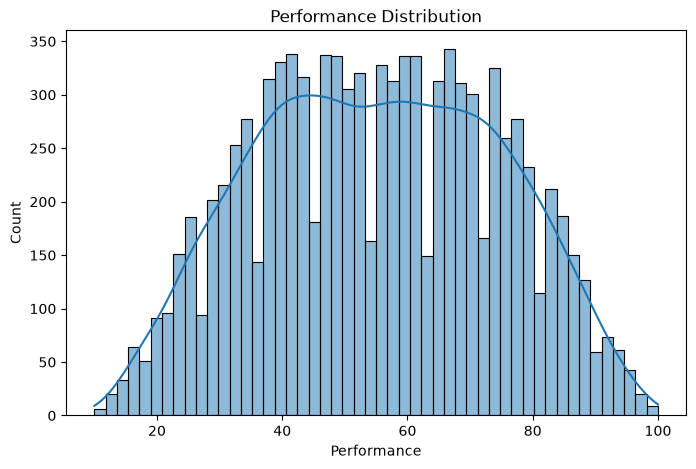

In [16]:
plt.figure(figsize = (8 , 5))
sns.histplot(df["Performance Index"] , bins = 50 , kde = True)

plt.title("Performance Distribution")
plt.xlabel("Performance")
plt.ylabel("Count")
plt.show()

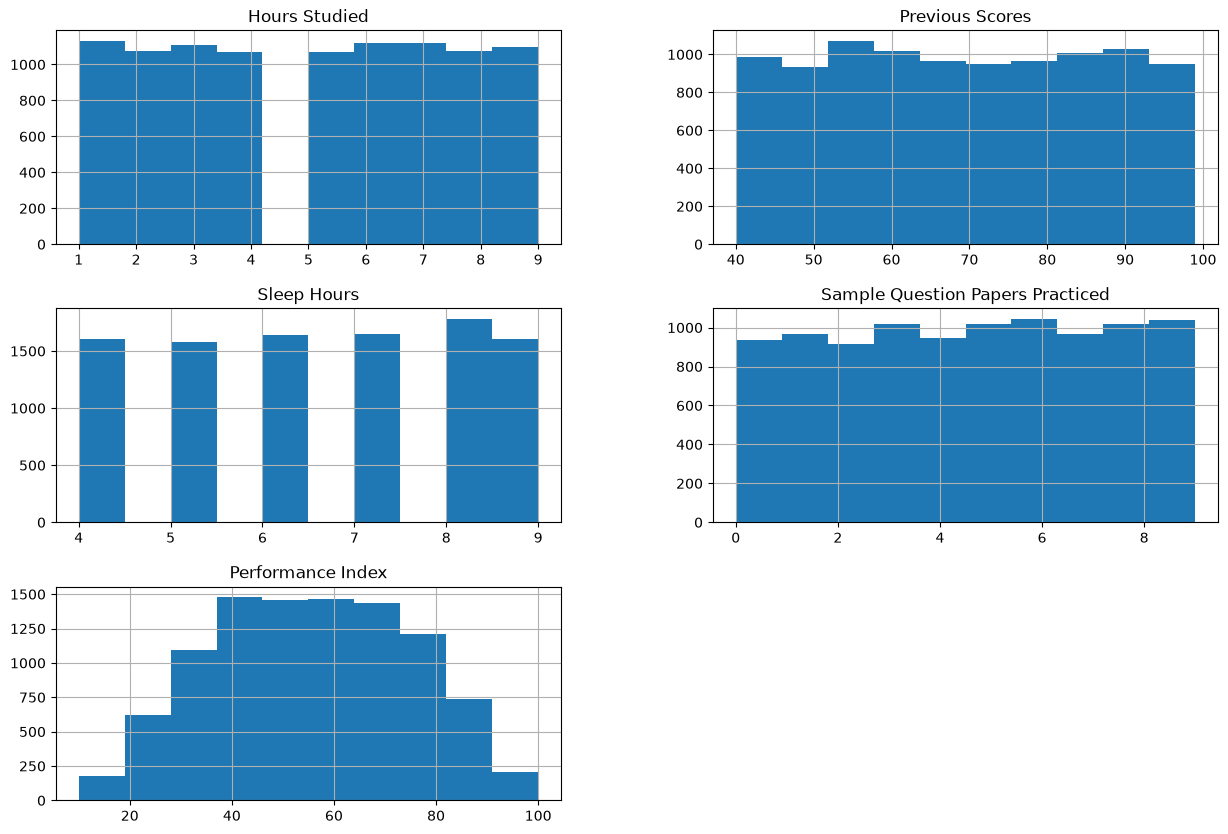

In [17]:
df.hist(figsize = (15 , 10))
plt.show()

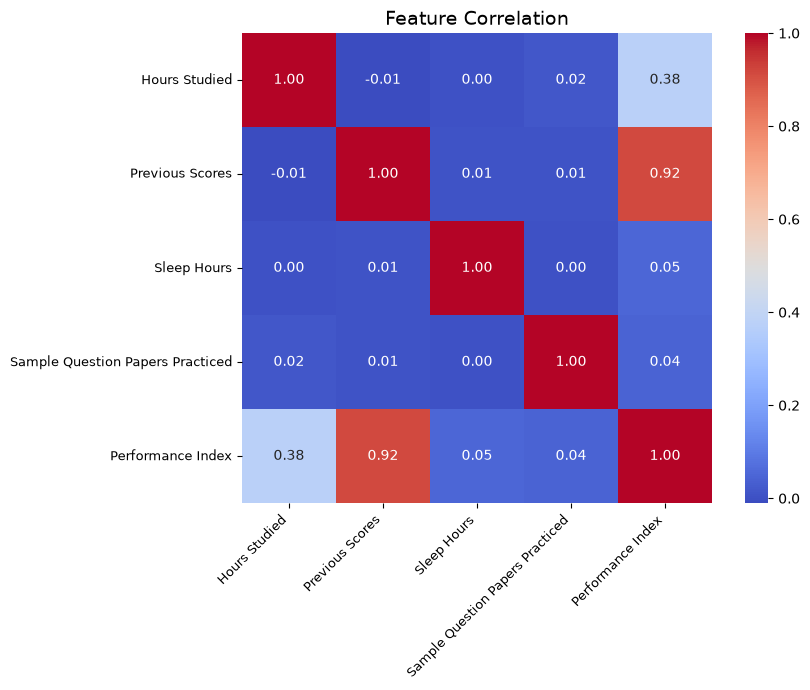

In [24]:
plt.figure(figsize = (9 , 7))
sns.heatmap(df.corr(numeric_only = True) , cmap = "coolwarm" , fmt = ".2f" , annot = True , square = True)

plt.title("Feature Correlation" , fontsize = 14)
plt.xticks(rotation = 45 , ha = "right" , fontsize = 9)
plt.yticks(rotation = 0 , fontsize = 9)
plt.tight_layout()
plt.show()

### Preprocessing Data

In [33]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col].astype(str))

### Feature & Target Split

In [45]:
X = df.drop(columns = ["Performance Index"])
y = df["Performance Index"]

### Train & Test Split

In [46]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 101)

### Model Training

In [49]:
final_model = LinearRegression(fit_intercept = True)
final_model.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Prediction

In [50]:
y_pred = final_model.predict(X_test)

### Evaluation

In [51]:
print("Final Model : Multiple Linear Regression")
print(f"MAE : {mean_absolute_error(y_test , y_pred)}")
print(f"MSE : {mean_squared_error(y_test , y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test , y_pred)}")
print(f"R2 Score : {r2_score(y_test , y_pred)}")

Final Model : Multiple Linear Regression
MAE : 1.6436051233462343
MSE : 4.266088184016613
RMSE : 2.065451084876283
R2 Score : 0.9881828541611042


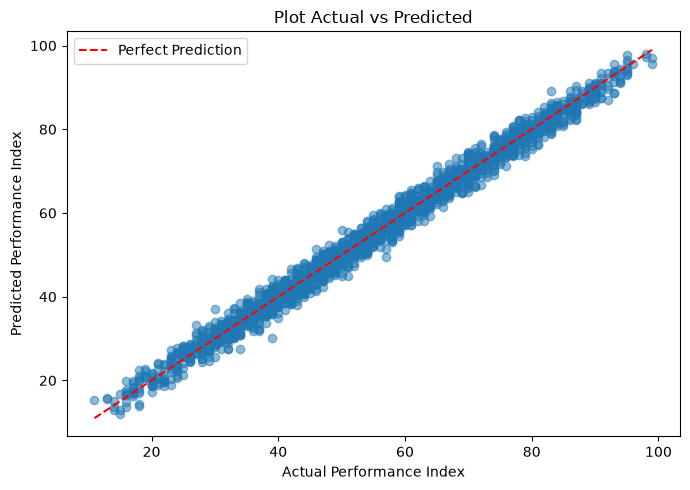

In [53]:
plt.figure(figsize = (7 , 5))
plt.scatter(y_test , y_pred , alpha = 0.5)
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , color = "red" , linestyle = "--" , label = "Perfect Prediction")

plt.title("Plot Actual vs Predicted")
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.tight_layout()
plt.legend()
plt.show()

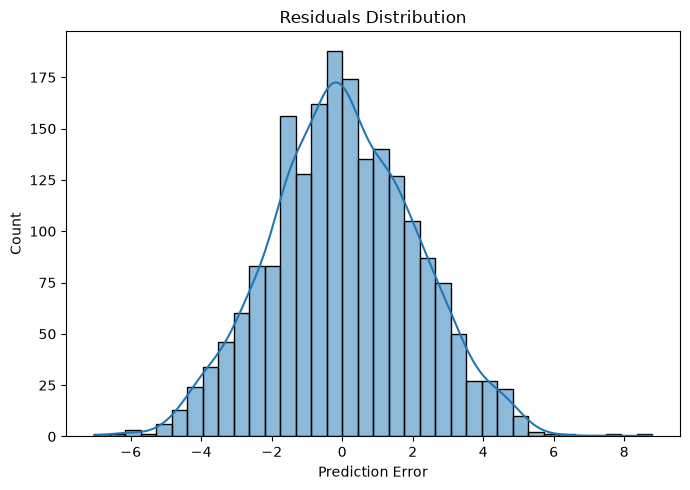

In [54]:
residuals = y_test - y_pred

plt.figure(figsize = (7 , 5))
sns.histplot(residuals , kde = True)

plt.title("Residuals Distribution")
plt.xlabel("Prediction Error")
plt.tight_layout()
plt.show()